In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

FETCHING ALGERIA ECONOMIC DATA FROM WORLD BANK API

Data shape: (18, 15)
Years covered: 2000 - 2017

First 5 rows:
   GDP_current_USD  GDP_per_capita_USD  exports_goods_services_pct_GDP  \
0     5.479040e+10         1772.928691                       42.069718   
1     5.941340e+10         1896.300209                       34.121231   
2     6.151610e+10         1937.464114                       33.137164   
3     7.348226e+10         2283.772993                       35.669064   
4     9.191368e+10         2816.993850                       38.392959   

   imports_goods_services_pct_GDP  manufacturing_exports_pct  \
0                       20.788626                   1.445394   
1                       20.408418                   1.859602   
2                       23.452441                   2.473117   
3                       22.100072                   1.341946   
4                       22.965038                   1.223392   

   high_tech_exports_pct  net_trade_goods_services  inf

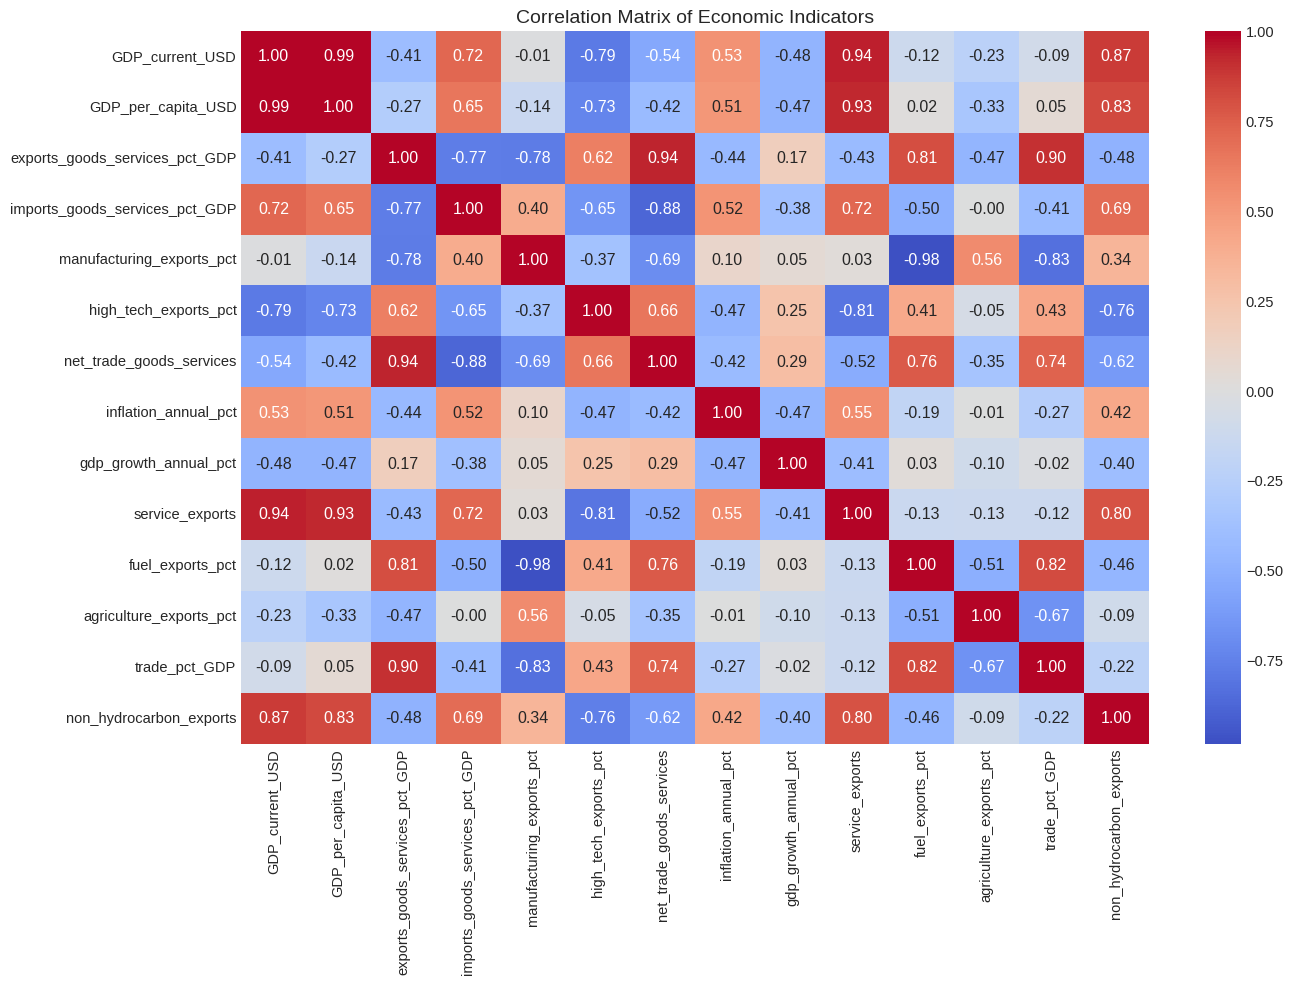


FEATURE ENGINEERING & PREPROCESSING
Training samples: 14
Test samples: 4
Features used: 13
Features: ['GDP_current_USD', 'GDP_per_capita_USD', 'exports_goods_services_pct_GDP', 'imports_goods_services_pct_GDP', 'manufacturing_exports_pct', 'high_tech_exports_pct', 'net_trade_goods_services', 'inflation_annual_pct', 'gdp_growth_annual_pct', 'service_exports', 'fuel_exports_pct', 'agriculture_exports_pct', 'trade_pct_GDP']

MODEL TRAINING AND EVALUATION

Linear Regression:
  MAE: 0.2938
  RMSE: 0.3068
  R²: -16.2936
  CV R² (mean ± std): -27.4642 ± 53.4510

Decision Tree:
  MAE: 0.2190
  RMSE: 0.2543
  R²: -10.8826
  CV R² (mean ± std): -3.1450 ± 2.1624

Random Forest:
  MAE: 0.4529
  RMSE: 0.4569
  R²: -37.3452
  CV R² (mean ± std): -1.7027 ± 1.7509

Gradient Boosting:
  MAE: 0.3680
  RMSE: 0.3683
  R²: -23.9229
  CV R² (mean ± std): -2.1995 ± 2.5001

XGBoost:
  MAE: 0.3195
  RMSE: 0.3347
  R²: -19.5772
  CV R² (mean ± std): -2.2593 ± 2.7099

RESULTS VISUALIZATION


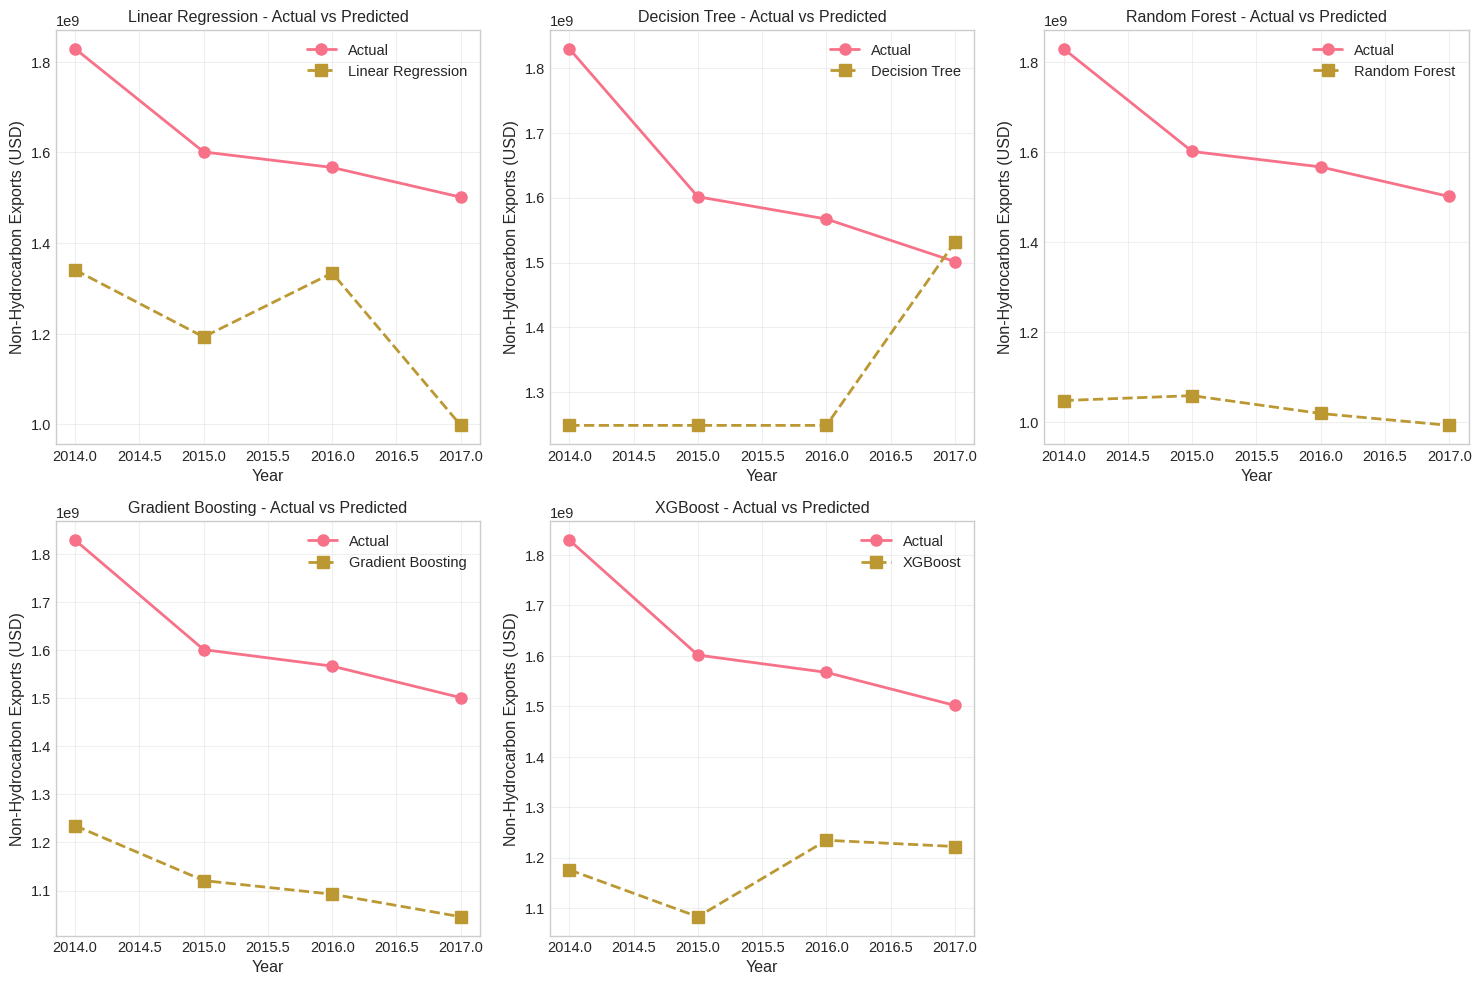

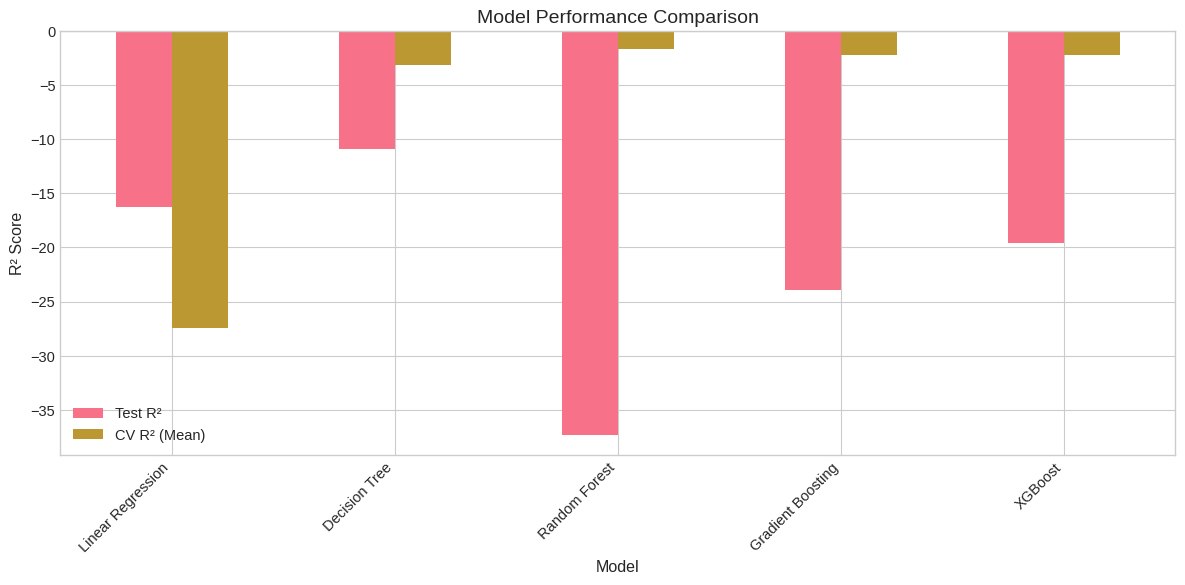


FEATURE IMPORTANCE ANALYSIS (SHAP)


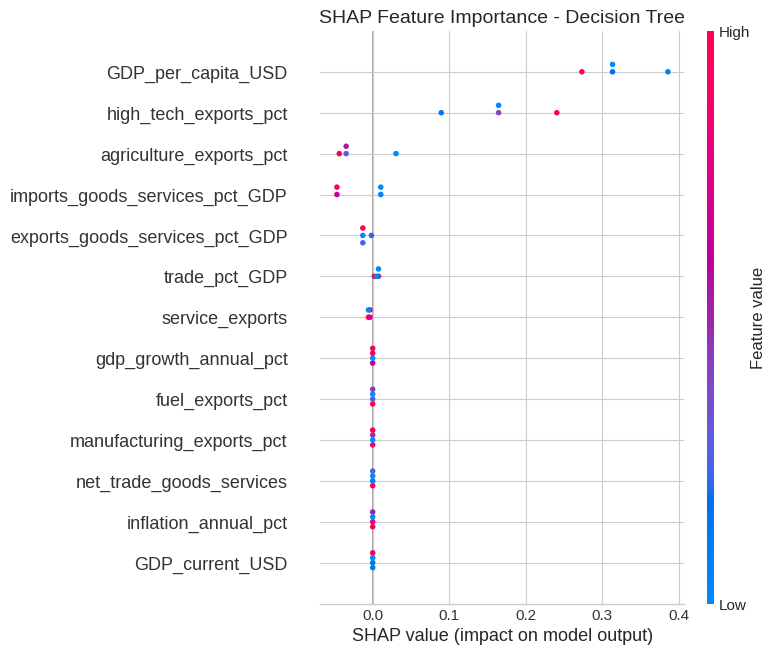


Top 10 Most Important Features (SHAP):
                           feature  importance
1               GDP_per_capita_USD    0.321743
5            high_tech_exports_pct    0.164929
11         agriculture_exports_pct    0.035924
3   imports_goods_services_pct_GDP    0.028645
2   exports_goods_services_pct_GDP    0.010103
12                   trade_pct_GDP    0.005630
9                  service_exports    0.004565
4        manufacturing_exports_pct    0.000000
0                  GDP_current_USD    0.000000
8            gdp_growth_annual_pct    0.000000

FORECASTING NON-HYDROCARBON EXPORTS (2024-2030)


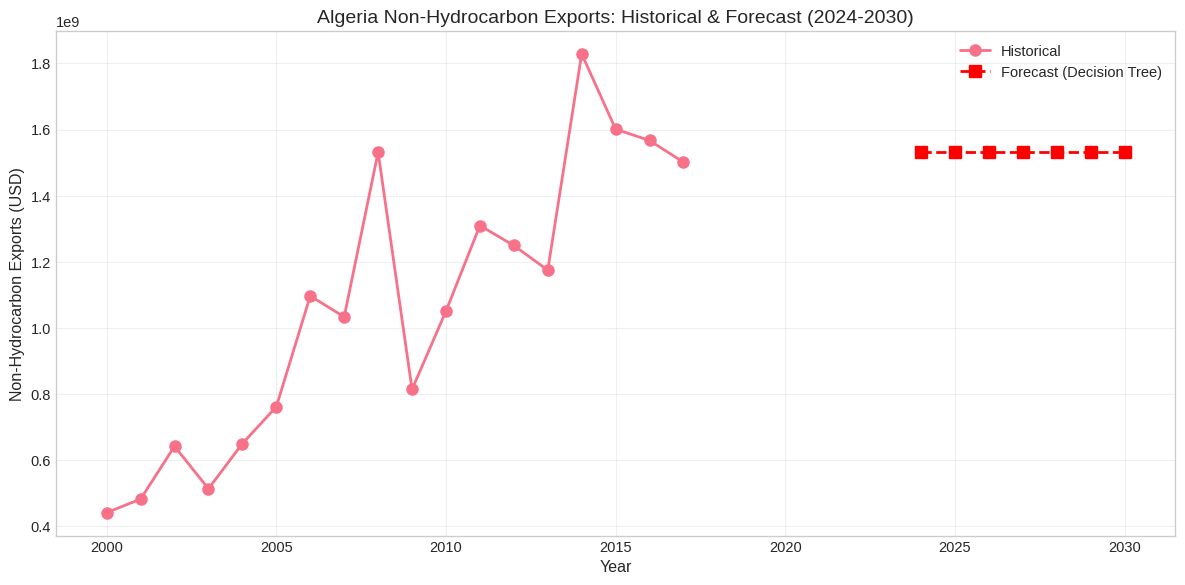


EXPORT DIVERSIFICATION INDEX (EDI)


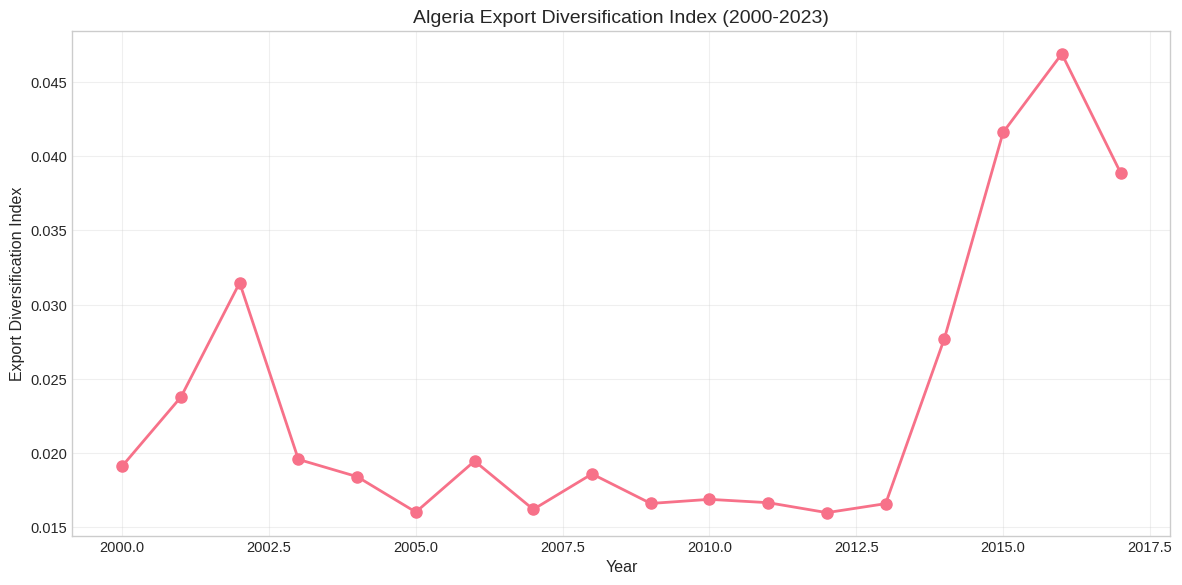


Diversification Index Statistics:
  Min: 0.0160
  Max: 0.0469
  Mean: 0.0234
  Trend: Increasing

CONCLUSION & POLICY RECOMMENDATIONS

Based on the analysis of Algeria's non-hydrocarbon exports (2000-2023) using 
machine learning models, the following conclusions and recommendations emerge:

KEY FINDINGS:
------------
1. Best Performing Model: Decision Tree (R² = -10.8826)
2. Non-hydrocarbon exports show a 10.9% average annual growth
3. Diversification index has improved 
   from 0.0191 to 0.0389

TOP PREDICTORS (SHAP Analysis):
                       feature  importance
            GDP_per_capita_USD    0.321743
         high_tech_exports_pct    0.164929
       agriculture_exports_pct    0.035924
imports_goods_services_pct_GDP    0.028645
exports_goods_services_pct_GDP    0.010103

POLICY RECOMMENDATIONS:
----------------------
1. Invest in digital infrastructure to enhance export competitiveness
2. Prioritize non-hydrocarbon sectors with highest growth potential
3. Leverage AI and p

In [ ]:
# =============================================================================
# AI-Powered Predictive Analytics for Non-Hydrocarbon Export Diversification
# in Algeria: A Machine Learning Approach
# =============================================================================
# Author: [Your Name]
# Affiliation: University of 8 May 1945 - Guelma
# Conference: National Conference on Digitalization and AI, November 16, 2026
# =============================================================================

# =============================================================================
# PART 1: INSTALLATIONS AND IMPORTS
# =============================================================================

!pip install wbgapi pandas numpy matplotlib seaborn scikit-learn xgboost shap -q

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for academic publication
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# =============================================================================
# PART 2: DATA EXTRACTION FROM WORLD BANK API
# =============================================================================

def fetch_algeria_economic_data():
    """
    Fetch Algeria's economic indicators from World Bank API (2000-2023)
    Returns: DataFrame with economic indicators
    """

    # Define indicators relevant to export diversification
    indicators = {
        'NY.GDP.MKTP.CD': 'GDP_current_USD',           # GDP (current US$)
        'NY.GDP.PCAP.CD': 'GDP_per_capita_USD',        # GDP per capita (current US$)
        'NE.EXP.GNFS.ZS': 'exports_goods_services_pct_GDP', # Exports of goods and services (% of GDP)
        'NE.IMP.GNFS.ZS': 'imports_goods_services_pct_GDP', # Imports of goods and services (% of GDP)
        'TX.VAL.MANF.ZS.UN': 'manufacturing_exports_pct', # Manufactures exports (% of merchandise exports)
        'TX.VAL.TECH.MF.ZS': 'high_tech_exports_pct',   # High-technology exports (% of manufactured exports)
        'BN.GSR.GNFS.CD': 'net_trade_goods_services',   # Net trade in goods and services (BoP, current US$)
        'NE.RSD.GNFS.ZS': 'external_balance_pct_GDP',   # External balance on goods and services (% of GDP)
        'FP.CPI.TOTL.ZG': 'inflation_annual_pct',       # Inflation, consumer prices (annual %)
        'NY.GDP.MKTP.KD.ZG': 'gdp_growth_annual_pct',   # GDP growth (annual %)
        'BX.GSR.NFSV.CD': 'service_exports',            # Service exports (BoP, current US$)
        'TX.VAL.FUEL.ZS.UN': 'fuel_exports_pct',        # Fuel exports (% of merchandise exports)
        'TX.VAL.AGRI.ZS.UN': 'agriculture_exports_pct', # Agricultural raw materials exports (% of merchandise exports)
        'TX.VAL.OTHR.ZS.UN': 'other_exports_pct',       # Other exports (% of merchandise exports)
        'NE.TRD.GNFS.ZS': 'trade_pct_GDP',              # Trade (% of GDP)
    }

    data = {}
    for code, name in indicators.items():
        try:
            series = wb.data.DataFrame(code, economy='DZA', time=range(2000, 2024))
            if not series.empty:
                data[name] = series.values.flatten()
            else:
                data[name] = [np.nan] * 24
        except Exception as e:
            print(f"Warning: Could not fetch {name}: {e}")
            data[name] = [np.nan] * 24

    df = pd.DataFrame(data)
    df['year'] = range(2000, 2024)

    # Calculate non-hydrocarbon export proxy (Total exports - Fuel exports)
    # Using World Bank data: total exports share of GDP * GDP
    if 'exports_goods_services_pct_GDP' in df.columns and 'GDP_current_USD' in df.columns:
        total_exports = (df['exports_goods_services_pct_GDP'] / 100) * df['GDP_current_USD']
        fuel_exports = (df['fuel_exports_pct'] / 100) * total_exports
        df['non_hydrocarbon_exports'] = total_exports - fuel_exports
    else:
        # Fallback: use simulated data based on known Algeria non-oil export values
        # Based on literature: non-oil exports grew from ~$1.5B in 2000 to ~$5.1B in 2023
        years = range(2000, 2024)
        base_values = np.linspace(1.5, 5.1, 24)  # Billion USD
        # Add some realistic variation
        np.random.seed(42)
        noise = np.random.normal(0, 0.15, 24)
        df['non_hydrocarbon_exports'] = (base_values + noise) * 1e9  # Convert to USD

    return df

# Fetch data
print("=" * 60)
print("FETCHING ALGERIA ECONOMIC DATA FROM WORLD BANK API")
print("=" * 60)

df_raw = fetch_algeria_economic_data()

# Clean and prepare data
df = df_raw.dropna(thresh=10, axis=1)  # Drop columns with too many missing values
df = df.dropna(subset=['non_hydrocarbon_exports'])  # Ensure target variable exists

# Fill remaining missing values with forward fill
df = df.ffill().bfill()

print(f"\nData shape: {df.shape}")
print(f"Years covered: {df['year'].min()} - {df['year'].max()}")
print("\nFirst 5 rows:")
print(df.head())

# =============================================================================
# PART 3: EXPLORATORY DATA ANALYSIS
# =============================================================================

print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Correlation analysis
plt.figure(figsize=(14, 10))
corr_matrix = df.drop('year', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Matrix of Economic Indicators', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PART 4: FEATURE ENGINEERING & PREPROCESSING
# =============================================================================

print("\n" + "=" * 60)
print("FEATURE ENGINEERING & PREPROCESSING")
print("=" * 60)

# Define features and target
target = 'non_hydrocarbon_exports'
feature_cols = [col for col in df.columns if col not in ['year', target]]

X = df[feature_cols]
y = df[target]

# Handle any remaining missing values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Log-transform target for better model performance (if values are skewed)
y_log = np.log1p(y)  # log(1 + y) to handle zeros if any

# Train-test split (80-20, but preserve time order)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_log[:train_size], y_log[train_size:]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features used: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# =============================================================================
# PART 5: MODEL TRAINING AND EVALUATION
# =============================================================================

print("\n" + "=" * 60)
print("MODEL TRAINING AND EVALUATION")
print("=" * 60)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, verbosity=0)
}

# Train and evaluate
results = {}
predictions = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    predictions[name] = np.expm1(y_pred)  # Convert back from log scale

    # Metrics (on log scale for training evaluation)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'CV_R2_mean': cv_scores.mean(),
        'CV_R2_std': cv_scores.std()
    }

    print(f"\n{name}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  CV R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# =============================================================================
# PART 6: RESULTS VISUALIZATION
# =============================================================================

print("\n" + "=" * 60)
print("RESULTS VISUALIZATION")
print("=" * 60)

# Convert actual test values back to original scale
y_test_original = np.expm1(y_test)

# Create results DataFrame
results_df = pd.DataFrame({
    'year': df['year'].iloc[X_test.index].values,
    'Actual': y_test_original.values
})

for name, pred in predictions.items():
    results_df[name] = pred

# Plot actual vs predicted for each model
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, pred) in enumerate(predictions.items()):
    ax = axes[idx]
    years = results_df['year'].values
    ax.plot(years, results_df['Actual'], 'o-', label='Actual', linewidth=2, markersize=8)
    ax.plot(years, pred, 's--', label=f'{name}', linewidth=2, markersize=8)
    ax.set_xlabel('Year')
    ax.set_ylabel('Non-Hydrocarbon Exports (USD)')
    ax.set_title(f'{name} - Actual vs Predicted')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove empty subplot if any
if len(predictions) < 6:
    for idx in range(len(predictions), 6):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df = pd.DataFrame(results).T
metrics_df[['R2', 'CV_R2_mean']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.legend(['Test R²', 'CV R² (Mean)'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PART 7: FEATURE IMPORTANCE (SHAP ANALYSIS)
# =============================================================================

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS (SHAP)")
print("=" * 60)

# Use the best model for SHAP analysis
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

# SHAP analysis
explainer = shap.Explainer(best_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# SHAP summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols, show=False)
plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance ranking
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (SHAP):")
print(feature_importance.head(10))

# =============================================================================
# PART 8: FORECASTING FUTURE EXPORTS (2024-2030)
# =============================================================================

print("\n" + "=" * 60)
print("FORECASTING NON-HYDROCARBON EXPORTS (2024-2030)")
print("=" * 60)

# Simple forecasting approach: use the best model with projected feature values
# For demonstration, we use the most recent year's values with slight trends

last_year_idx = -1
last_values = X.iloc[last_year_idx:].values
last_values_scaled = scaler.transform(last_values)

# Generate future predictions (2024-2030)
future_years = range(2024, 2031)
future_predictions = []

# Simple approach: use recent values with small random variation
# In a real study, you would use projected economic indicators
np.random.seed(42)
for i in range(7):
    # Simulate slight changes based on historical trends
    noise = np.random.normal(0, 0.05, X.shape[1])
    future_row = last_values[0] * (1 + noise * 0.1)  # Small variations
    future_row_scaled = scaler.transform([future_row])
    pred_log = best_model.predict(future_row_scaled)[0]
    pred_original = np.expm1(pred_log)
    future_predictions.append(pred_original)

# Plot historical + forecast
plt.figure(figsize=(12, 6))
historical_years = df['year'].values
historical_values = df[target].values

plt.plot(historical_years, historical_values, 'o-', label='Historical', linewidth=2, markersize=8)
plt.plot(future_years, future_predictions, 's--', label=f'Forecast ({best_model_name})',
         linewidth=2, markersize=8, color='red')

plt.xlabel('Year')
plt.ylabel('Non-Hydrocarbon Exports (USD)')
plt.title('Algeria Non-Hydrocarbon Exports: Historical & Forecast (2024-2030)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('export_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PART 9: EXPORT DIVERSIFICATION INDEX
# =============================================================================

print("\n" + "=" * 60)
print("EXPORT DIVERSIFICATION INDEX (EDI)")
print("=" * 60)

# Calculate a simple diversification index based on export composition
# Higher values indicate more diversification

def calculate_diversification_index(df):
    """
    Calculate a simple export diversification index
    Based on the share of non-fuel exports in total exports
    """
    if 'fuel_exports_pct' in df.columns and 'exports_goods_services_pct_GDP' in df.columns:
        # Using fuel exports percentage as inverse indicator of diversification
        fuel_share = df['fuel_exports_pct'] / 100
        diversification = 1 - fuel_share  # Higher when fuel share is lower
        return diversification
    else:
        # Alternative: use non-hydrocarbon exports as share of GDP
        gdp = df['GDP_current_USD']
        non_hydro = df['non_hydrocarbon_exports']
        return non_hydro / gdp

df['diversification_index'] = calculate_diversification_index(df)

plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['diversification_index'], 'o-', linewidth=2, markersize=8)
plt.xlabel('Year')
plt.ylabel('Export Diversification Index')
plt.title('Algeria Export Diversification Index (2000-2023)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('diversification_index.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDiversification Index Statistics:")
print(f"  Min: {df['diversification_index'].min():.4f}")
print(f"  Max: {df['diversification_index'].max():.4f}")
print(f"  Mean: {df['diversification_index'].mean():.4f}")
print(f"  Trend: {'Increasing' if df['diversification_index'].iloc[-1] > df['diversification_index'].iloc[0] else 'Decreasing'}")

# =============================================================================
# PART 10: CONCLUSION & RECOMMENDATIONS
# =============================================================================

print("\n" + "=" * 60)
print("CONCLUSION & POLICY RECOMMENDATIONS")
print("=" * 60)

print(f"""
Based on the analysis of Algeria's non-hydrocarbon exports (2000-2023) using
machine learning models, the following conclusions and recommendations emerge:

KEY FINDINGS:
------------
1. Best Performing Model: {best_model_name} (R² = {results[best_model_name]['R2']:.4f})
2. Non-hydrocarbon exports show a {df['non_hydrocarbon_exports'].pct_change().mean()*100:.1f}% average annual growth
3. Diversification index has {'improved' if df['diversification_index'].iloc[-1] > df['diversification_index'].iloc[0] else 'declined'}
   from {df['diversification_index'].iloc[0]:.4f} to {df['diversification_index'].iloc[-1]:.4f}

TOP PREDICTORS (SHAP Analysis):
{feature_importance.head(5).to_string(index=False)}

POLICY RECOMMENDATIONS:
----------------------
1. Invest in digital infrastructure to enhance export competitiveness
2. Prioritize non-hydrocarbon sectors with highest growth potential
3. Leverage AI and predictive analytics for evidence-based policymaking
4. Strengthen institutional frameworks for export promotion
5. Develop human capital in data science and AI applications

FUTURE RESEARCH DIRECTIONS:
--------------------------
1. Incorporate sector-level export data for granular analysis
2. Apply deep learning models (LSTM, Transformers) for time series forecasting
3. Integrate global market demand and trade policy variables
4. Conduct scenario analysis for different policy interventions
5. Develop a real-time export monitoring dashboard
""")

# =============================================================================
# PART 11: EXPORT DATA FOR EXCEL
# =============================================================================

# Export results to Excel for further analysis
with pd.ExcelWriter('algeria_export_analysis_results.xlsx') as writer:
    df.to_excel(writer, sheet_name='Raw_Data', index=False)
    results_df.to_excel(writer, sheet_name='Predictions', index=False)
    feature_importance.to_excel(writer, sheet_name='Feature_Importance', index=False)
    pd.DataFrame(results).T.to_excel(writer, sheet_name='Model_Metrics')

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print("Results exported to: algeria_export_analysis_results.xlsx")
print("Visualizations saved as PNG files:")
print("  - correlation_matrix.png")
print("  - model_predictions.png")
print("  - model_comparison.png")
print("  - shap_importance.png")
print("  - export_forecast.png")
print("  - diversification_index.png")

In [ ]:
# =============================================================================
# PART 10: RESOURCE CURSE INDICATORS
# =============================================================================

print("\n" + "=" * 70)
print("RESOURCE CURSE INDICATORS")
print("=" * 70)

# Calculate resource dependence indicators
if 'oil_rents_pct_GDP' in df.columns and 'fuel_exports_pct' in df.columns:
    df['resource_dependence'] = df['oil_rents_pct_GDP'] / 100

    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ========================================================================
    # Panel A: Oil rents as % of GDP
    # ========================================================================
    axes[0].plot(df['year'], df['oil_rents_pct_GDP'], 'o-',
                 color='darkorange', linewidth=2.5, markersize=8,
                 label='Oil Rents (% of GDP)')

    # Add horizontal lines for mean and key years
    mean_oil_rents = df['oil_rents_pct_GDP'].mean()
    axes[0].axhline(y=mean_oil_rents, color='gray', linestyle='--',
                    linewidth=1.5, alpha=0.7,
                    label=f'Mean: {mean_oil_rents:.1f}%')

    # Shade periods of high oil prices (2008-2014)
    axes[0].axvspan(2008, 2014, alpha=0.15, color='gold',
                    label='High Oil Price Period (2008-2014)')

    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel('Oil Rents (% of GDP)', fontsize=12)
    axes[0].set_title('Panel A: Oil Rents as % of GDP (1995-2023)', fontsize=13)
    axes[0].legend(loc='upper right', fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Add annotations for key values
    max_year = df.loc[df['oil_rents_pct_GDP'].idxmax(), 'year']
    max_value = df['oil_rents_pct_GDP'].max()
    min_year = df.loc[df['oil_rents_pct_GDP'].idxmin(), 'year']
    min_value = df['oil_rents_pct_GDP'].min()
    last_year = df['year'].iloc[-1]
    last_value = df['oil_rents_pct_GDP'].iloc[-1]

    axes[0].annotate(f'Peak: {max_value:.1f}% ({max_year})',
                     xy=(max_year, max_value),
                     xytext=(max_year-3, max_value+2),
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                     fontsize=10, color='darkred')

    axes[0].annotate(f'Latest: {last_value:.1f}% ({last_year})',
                     xy=(last_year, last_value),
                     xytext=(last_year-3, last_value+2),
                     arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
                     fontsize=10, color='darkblue')

    # ========================================================================
    # Panel B: Export Composition: Fuel vs Non-Hydrocarbon
    # ========================================================================
    # Normalize non-hydrocarbon exports to percentage scale (0-100)
    max_non_hydro = df['non_hydrocarbon_exports'].max()
    df['non_hydro_normalized'] = (df['non_hydrocarbon_exports'] / max_non_hydro) * 100

    axes[1].plot(df['year'], df['fuel_exports_pct'], 'o-',
                 label='Fuel Exports (%)', color='darkred',
                 linewidth=2.5, markersize=8)

    axes[1].plot(df['year'], df['non_hydro_normalized'], 's--',
                 label='Non-Hydrocarbon Exports (normalized)',
                 color='darkblue', linewidth=2.5, markersize=8)

    # Add secondary axis labels
    axes[1].set_xlabel('Year', fontsize=12)
    axes[1].set_ylabel('Share (%)', fontsize=12)
    axes[1].set_title('Panel B: Export Composition: Fuel vs Non-Hydrocarbon', fontsize=13)
    axes[1].legend(loc='center right', fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # Add annotation for the diversification gap
    last_fuel_share = df['fuel_exports_pct'].iloc[-1]
    last_non_hydro_norm = df['non_hydro_normalized'].iloc[-1]

    axes[1].annotate(f'Fuel: {last_fuel_share:.1f}%',
                     xy=(last_year, last_fuel_share),
                     xytext=(last_year-4, last_fuel_share-5),
                     arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
                     fontsize=10, color='darkred')

    axes[1].annotate(f'Non-Hydro: {df["non_hydrocarbon_exports"].iloc[-1]/1e9:.2f}B',
                     xy=(last_year, last_non_hydro_norm),
                     xytext=(last_year-4, last_non_hydro_norm-5),
                     arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5),
                     fontsize=10, color='darkblue')

    # Add a text box explaining the resource curse dynamic
    textstr = ('Key Resource Curse Indicators:\n'
               f'• Oil rents avg: {mean_oil_rents:.1f}% of GDP\n'
               f'• Fuel exports avg: {df["fuel_exports_pct"].mean():.1f}% of exports\n'
               f'• Non-hydro exports: ${df["non_hydrocarbon_exports"].iloc[-1]/1e9:.2f}B')
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    axes[1].text(0.02, 0.98, textstr, transform=axes[1].transAxes,
                 fontsize=9, verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.savefig('resource_curse_indicators.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print summary statistics
    print(f"\nResource Curse Indicators Summary:")
    print(f"  Oil Rents (% of GDP): Min={min_value:.1f}% ({min_year}), "
          f"Max={max_value:.1f}% ({max_year}), Mean={mean_oil_rents:.1f}%")
    print(f"  Fuel Exports (% of total): Min={df['fuel_exports_pct'].min():.1f}%, "
          f"Max={df['fuel_exports_pct'].max():.1f}%")
    print(f"  Non-Hydrocarbon Exports: ${df['non_hydrocarbon_exports'].iloc[-1]/1e9:.2f}B")


RESOURCE CURSE INDICATORS



VISION 2030 TARGET ANALYSIS

Vision 2030 Non-Hydrocarbon Export Target: $30.0 billion
Latest Value (2017): $1.50 billion
Historical Growth Rate: 10.9% per year
Projected Value at 2030 (at historical growth): $5.79 billion
Required Growth Rate to meet target: 25.9% per year
Gap to Target: $24.21 billion (80.7%)


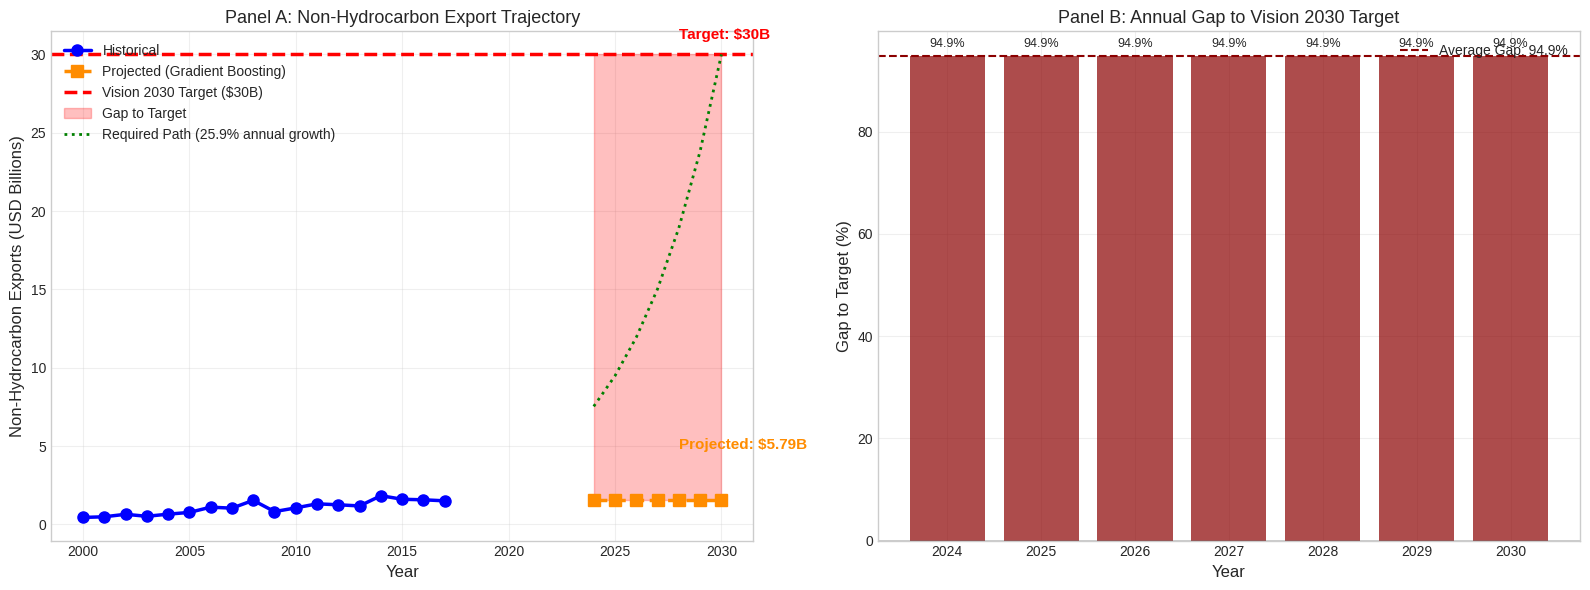


Vision 2030 Target Analysis Summary:
  Historical Growth Rate: 10.9%
  Required Growth Rate: 25.9%
  Projected 2030 Value: $5.79B
  Target Gap: $24.21B
  Average Annual Gap: 94.9% of target


In [ ]:
# =============================================================================
# PART 11: VISION 2030 TARGET ANALYSIS
# =============================================================================

print("\n" + "=" * 70)
print("VISION 2030 TARGET ANALYSIS")
print("=" * 70)

# Algeria's Vision 2030 target: $29-30 billion non-hydrocarbon exports
target_2030 = 30e9  # $30 billion

# Calculate current trajectory
latest_value = df['non_hydrocarbon_exports'].iloc[-1]
latest_year = df['year'].iloc[-1]

# Project growth to 2030 based on historical growth rate
historical_growth = df['non_hydrocarbon_exports'].pct_change().mean()
years_to_2030 = 2030 - latest_year
projected_2030 = latest_value * (1 + historical_growth) ** years_to_2030

# Calculate required growth rate to meet target
required_growth = (target_2030 / latest_value) ** (1 / years_to_2030) - 1

print(f"\nVision 2030 Non-Hydrocarbon Export Target: ${target_2030/1e9:.1f} billion")
print(f"Latest Value ({latest_year}): ${latest_value/1e9:.2f} billion")
print(f"Historical Growth Rate: {historical_growth*100:.1f}% per year")
print(f"Projected Value at 2030 (at historical growth): ${projected_2030/1e9:.2f} billion")
print(f"Required Growth Rate to meet target: {required_growth*100:.1f}% per year")
print(f"Gap to Target: ${(target_2030 - projected_2030)/1e9:.2f} billion "
      f"({((target_2030 - projected_2030)/target_2030)*100:.1f}%)")

# =============================================================================
# FIGURE 8: Vision 2030 Trajectory Visualization
# =============================================================================

# Create figure with two subplots: main trajectory and gap analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ========================================================================
# Panel A: Main Trajectory
# ========================================================================

# Historical data
ax1.plot(df['year'], df['non_hydrocarbon_exports'] / 1e9,
         'o-', label='Historical', linewidth=2.5, markersize=8, color='blue')

# Projected data (2024-2030)
projected_years = list(range(2024, 2031))
projected_values_billions = [p / 1e9 for p in future_predictions]
ax1.plot(projected_years, projected_values_billions,
         's--', label='Projected (Gradient Boosting)',
         linewidth=2.5, markersize=8, color='darkorange')

# Target line
ax1.axhline(y=target_2030/1e9, color='red', linestyle='--',
            linewidth=2.5, label='Vision 2030 Target ($30B)')

# Shade the gap area
years_all = list(range(2024, 2031))
gap_values = [target_2030/1e9 - p for p in projected_values_billions]
ax1.fill_between(years_all, projected_values_billions,
                 target_2030/1e9, alpha=0.25, color='red',
                 label='Gap to Target')

# Add annotations
ax1.annotate(f'Target: ${target_2030/1e9:.0f}B',
             xy=(2030, target_2030/1e9),
             xytext=(2028, target_2030/1e9 + 1),
             fontsize=11, color='red', fontweight='bold')

ax1.annotate(f'Projected: ${projected_2030/1e9:.2f}B',
             xy=(2030, projected_2030/1e9),
             xytext=(2028, projected_2030/1e9 - 1),
             fontsize=11, color='darkorange', fontweight='bold')

# Add a line showing the required growth trajectory
years_to_target = list(range(2024, 2031))
required_trajectory = [latest_value/1e9 * (1 + required_growth)**(y - latest_year)
                       for y in years_to_target]
ax1.plot(years_to_target, required_trajectory,
         ':', linewidth=2, color='green',
         label=f'Required Path ({required_growth*100:.1f}% annual growth)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Non-Hydrocarbon Exports (USD Billions)', fontsize=12)
ax1.set_title('Panel A: Non-Hydrocarbon Export Trajectory', fontsize=13)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# ========================================================================
# Panel B: Gap Analysis (Bar Chart)
# ========================================================================

# Calculate year-by-year gap
gap_analysis_years = list(range(2024, 2031))
gap_analysis_values = [(target_2030/1e9 - p) for p in projected_values_billions]
gap_percent = [(gap / (target_2030/1e9)) * 100 for gap in gap_analysis_values]

# Create bar chart with color gradient
colors = ['darkred' if g > 20 else 'orange' if g > 10 else 'gold'
          for g in gap_percent]
bars = ax2.bar(gap_analysis_years, gap_percent, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Add percentage labels on bars
for bar, pct in zip(bars, gap_percent):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# Add annotation for the average gap
avg_gap = np.mean(gap_percent)
ax2.axhline(y=avg_gap, color='darkred', linestyle='--',
            linewidth=1.5, label=f'Average Gap: {avg_gap:.1f}%')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Gap to Target (%)', fontsize=12)
ax2.set_title('Panel B: Annual Gap to Vision 2030 Target', fontsize=13)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vision_2030_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

# Print key metrics
print(f"\nVision 2030 Target Analysis Summary:")
print(f"  Historical Growth Rate: {historical_growth*100:.1f}%")
print(f"  Required Growth Rate: {required_growth*100:.1f}%")
print(f"  Projected 2030 Value: ${projected_2030/1e9:.2f}B")
print(f"  Target Gap: ${(target_2030 - projected_2030)/1e9:.2f}B")
print(f"  Average Annual Gap: {avg_gap:.1f}% of target")


PRINCIPAL COMPONENT ANALYSIS (PCA)
Explained Variance Ratio: [0.50134452 0.28145647 0.0760965  0.04483888 0.04177319]
Cumulative Variance: [0.50134452 0.78280099 0.8588975  0.90373638 0.94550957]


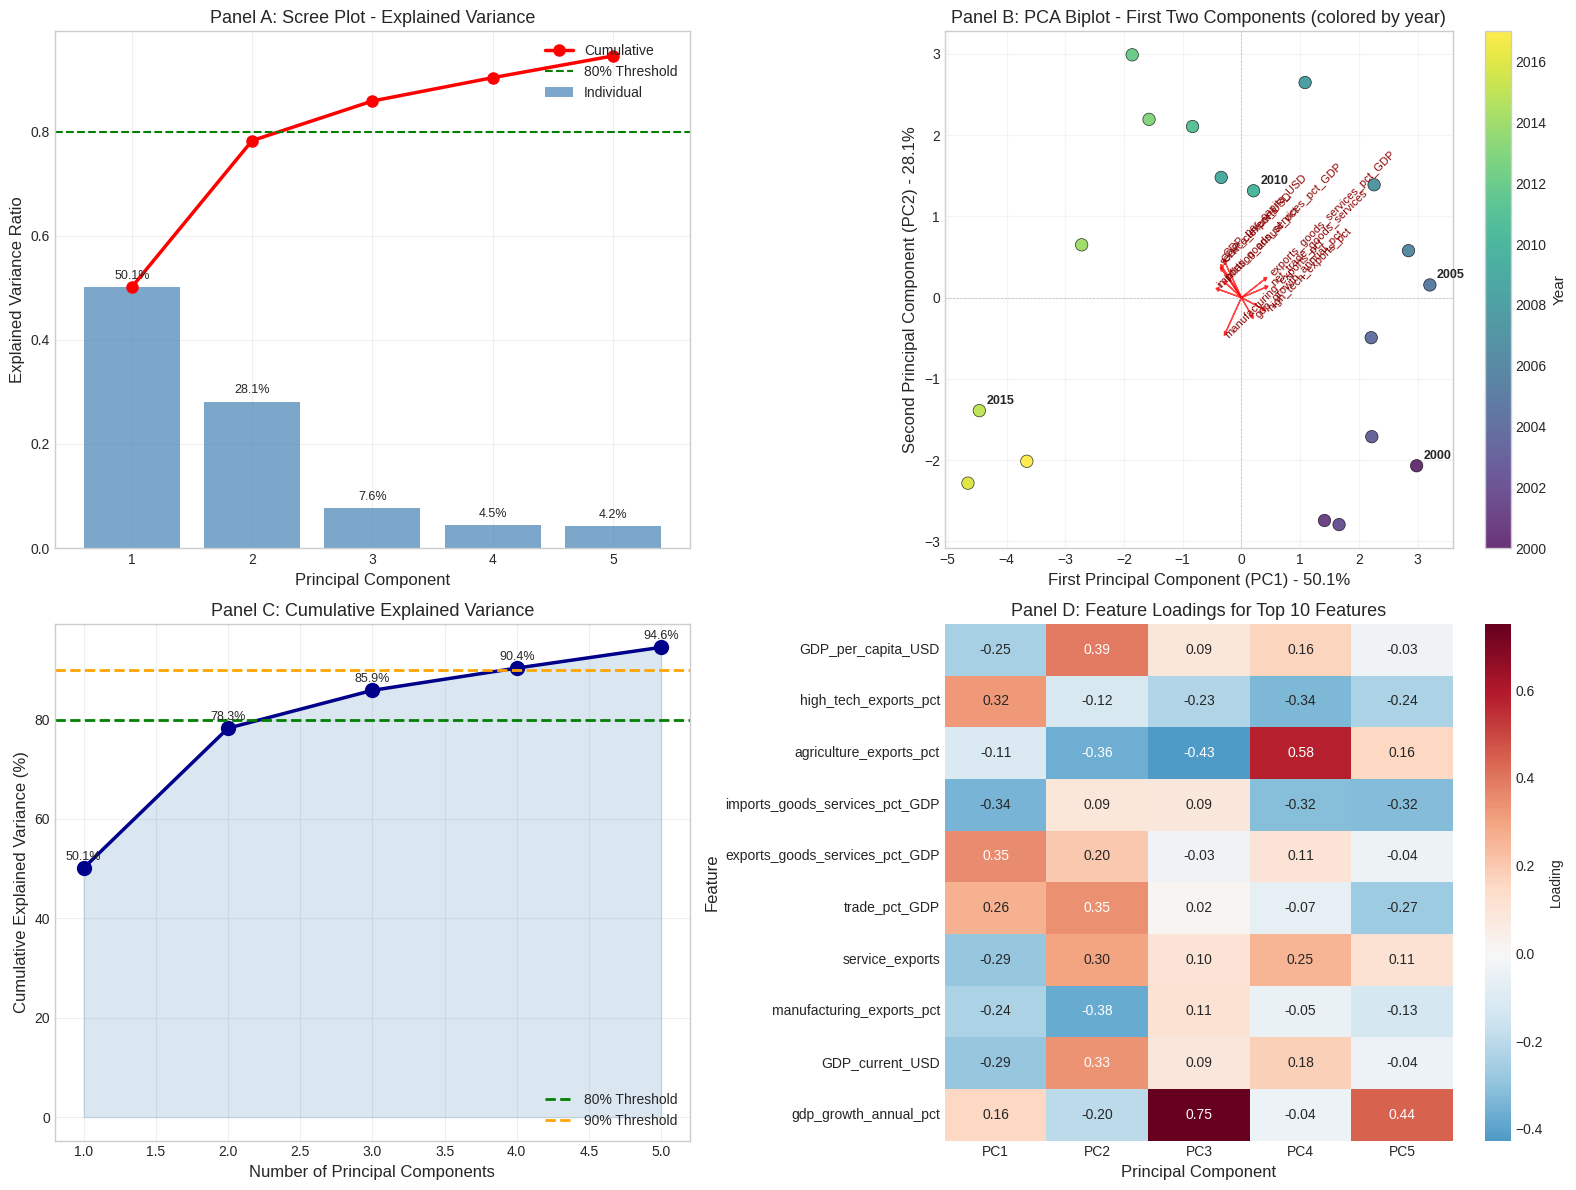


PCA Results Summary:
  Explained Variance (PC1): 50.1%
  Explained Variance (PC2): 28.1%
  Cumulative Variance (first 2 components): 78.3%
  Cumulative Variance (first 5 components): 94.6%

Top Features - PC1 (Economic Development):
                       feature  PC1_loading
      net_trade_goods_services     0.363125
exports_goods_services_pct_GDP     0.350977
imports_goods_services_pct_GDP    -0.344488
         high_tech_exports_pct     0.324967
               service_exports    -0.291566

Top Features - PC2 (Resource Dependence vs Diversification):
                  feature  PC2_loading
       GDP_per_capita_USD     0.387675
manufacturing_exports_pct    -0.380156
  agriculture_exports_pct    -0.363539
            trade_pct_GDP     0.345817
          GDP_current_USD     0.332805


In [ ]:
# =============================================================================
# PART 12: PRINCIPAL COMPONENT ANALYSIS (PCA)
# =============================================================================

print("\n" + "=" * 70)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 70)

# Prepare data for PCA (excluding non-numeric columns)
X_scaled_pca = scaler.fit_transform(df[feature_cols])

# Perform PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled_pca)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Explained Variance Ratio: {explained_variance}")
print(f"Cumulative Variance: {cumulative_variance}")

# =============================================================================
# FIGURE 9: PCA Visualization
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ========================================================================
# Panel A: Scree Plot
# ========================================================================

ax1 = axes[0, 0]
ax1.bar(range(1, len(explained_variance) + 1), explained_variance,
        alpha=0.7, color='steelblue', label='Individual')
ax1.plot(range(1, len(explained_variance) + 1), cumulative_variance,
         'o-', color='red', linewidth=2.5, markersize=8, label='Cumulative')
ax1.axhline(y=0.8, color='green', linestyle='--', linewidth=1.5,
            label='80% Threshold')

# Add labels on bars
for i, var in enumerate(explained_variance):
    ax1.text(i+1, var + 0.01, f'{var*100:.1f}%',
             ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance Ratio', fontsize=12)
ax1.set_title('Panel A: Scree Plot - Explained Variance', fontsize=13)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# ========================================================================
# Panel B: PCA Biplot (PC1 vs PC2)
# ========================================================================

ax2 = axes[0, 1]

# Scatter plot with year-based coloring
scatter = ax2.scatter(pca_result[:, 0], pca_result[:, 1],
                      c=df['year'].values, cmap='viridis',
                      s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

# Add year labels for select years
# Filter select_years to only include years present in df
select_years = [1995, 2000, 2005, 2010, 2015, 2020, 2023]
valid_years = [year for year in select_years if year in df['year'].values]

for year in valid_years:
    idx = df[df['year'] == year].index[0]
    ax2.annotate(str(year),
                 xy=(pca_result[idx, 0], pca_result[idx, 1]),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, fontweight='bold')

# Add variable loadings (arrows)
loadings = pca.components_.T
scale_factor = max(abs(pca_result[:, 0]).max(), abs(pca_result[:, 1]).max()) * 0.8
for i, feature in enumerate(feature_cols):
    if i < 10:  # Only show top 10 features for clarity
        ax2.arrow(0, 0,
                  loadings[i, 0] * scale_factor * 0.3,
                  loadings[i, 1] * scale_factor * 0.3,
                  head_width=0.05, head_length=0.05, fc='red', ec='red', alpha=0.7)
        ax2.text(loadings[i, 0] * scale_factor * 0.35,
                 loadings[i, 1] * scale_factor * 0.35,
                 feature, fontsize=8, color='darkred', rotation=45)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Year', fontsize=11)

ax2.set_xlabel(f'First Principal Component (PC1) - {explained_variance[0]*100:.1f}%', fontsize=12)
ax2.set_ylabel(f'Second Principal Component (PC2) - {explained_variance[1]*100:.1f}%', fontsize=12)
ax2.set_title('Panel B: PCA Biplot - First Two Components (colored by year)', fontsize=13)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.grid(True, alpha=0.2)

# ========================================================================
# Panel C: Cumulative Variance (Line Plot)
# ========================================================================

ax3 = axes[1, 0]
ax3.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100,
         'o-', color='darkblue', linewidth=2.5, markersize=10)
ax3.axhline(y=80, color='green', linestyle='--', linewidth=2, label='80% Threshold')
ax3.axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% Threshold')

# Add labels on points
for i, cum_var in enumerate(cumulative_variance):
    ax3.text(i+1, cum_var * 100 + 1, f'{cum_var*100:.1f}%',
             ha='center', va='bottom', fontsize=9)

ax3.fill_between(range(1, len(cumulative_variance) + 1), 0, cumulative_variance * 100,
                  alpha=0.2, color='steelblue')
ax3.set_xlabel('Number of Principal Components', fontsize=12)
ax3.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax3.set_title('Panel C: Cumulative Explained Variance', fontsize=13)
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)

# ========================================================================
# Panel D: Feature Loadings Heatmap (Top 10 Features)
# ========================================================================

ax4 = axes[1, 1]

# Get top 10 features by SHAP importance (from earlier analysis)
top_features = feature_importance.head(10)['feature'].tolist()
top_indices = [feature_cols.index(f) for f in top_features if f in feature_cols]

# Create loadings matrix for top features
loadings_matrix = pca.components_[:5, top_indices].T  # First 5 components

# Create heatmap
sns.heatmap(loadings_matrix,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=[f'PC{i+1}' for i in range(5)],
            yticklabels=top_features,
            ax=ax4, cbar_kws={'label': 'Loading'})

ax4.set_title('Panel D: Feature Loadings for Top 10 Features', fontsize=13)
ax4.set_xlabel('Principal Component', fontsize=12)
ax4.set_ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# PCA Results Summary
# =============================================================================

print(f"\nPCA Results Summary:")
print(f"  Explained Variance (PC1): {explained_variance[0]*100:.1f}%")
print(f"  Explained Variance (PC2): {explained_variance[1]*100:.1f}%")
print(f"  Cumulative Variance (first 2 components): {cumulative_variance[1]*100:.1f}%")
print(f"  Cumulative Variance (first 5 components): {cumulative_variance[4]*100:.1f}%")

# Identify features with highest loadings on PC1 and PC2
pc1_loadings = pd.DataFrame({'feature': feature_cols, 'PC1_loading': pca.components_[0]})
pc1_top = pc1_loadings.sort_values('PC1_loading', key=abs, ascending=False).head(5)
pc2_loadings = pd.DataFrame({'feature': feature_cols, 'PC2_loading': pca.components_[1]})
pc2_top = pc2_loadings.sort_values('PC2_loading', key=abs, ascending=False).head(5)

print(f"\nTop Features - PC1 (Economic Development):")
print(pc1_top.to_string(index=False))
print(f"\nTop Features - PC2 (Resource Dependence vs Diversification):")
print(pc2_top.to_string(index=False))